# iter_3 Macro Autoresearch Analysis

Validation CAGR is the selection objective subject to no ruin. Locked OOS and DBMF excess are diagnostics only.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
results = pd.read_csv(Path('results.tsv'), sep='\t')
numeric_cols = ['train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf']
for col in numeric_cols:
    results[col] = pd.to_numeric(results[col], errors="coerce")
results['trial'] = range(1, len(results) + 1)
results['ruined_flag'] = results['ruined'].astype(str).str.lower().isin(['true', '1'])
eligible = results[(~results['ruined_flag']) & (results['validation_cagr'] > 0)].copy()
best = eligible.loc[eligible['validation_cagr'].idxmax()]
keeps = results[results['status'] == 'keep'].copy()
summary = pd.DataFrame([{'rows': len(results), 'keeps': len(keeps), 'ruined': int(results['ruined_flag'].sum()), 'best_idea_id': best['idea_id'], 'best_validation_cagr': best['validation_cagr'], 'best_train_cagr': best['train_cagr'], 'best_oos_cagr': best['oos_cagr'], 'best_benchmark_oos_cagr': best['benchmark_oos_cagr'], 'best_excess_oos_cagr_vs_dbmf': best['excess_oos_cagr_vs_dbmf']}])
summary


,rows,keeps,ruined,best_idea_id,best_validation_cagr,best_train_cagr,best_oos_cagr,best_benchmark_oos_cagr,best_excess_oos_cagr_vs_dbmf
0,41,4,0,sector_top2_1m_scoreweight_024,0.33355,0.096288,0.627231,0.175971,0.451259


In [2]:
display_cols = ['trial', 'idea_id', 'status', 'train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf', 'ruined', 'description']
results.sort_values('validation_cagr', ascending=False)[display_cols].head(12)


,trial,idea_id,status,train_cagr,validation_cagr,oos_cagr,benchmark_oos_cagr,excess_oos_cagr_vs_dbmf,ruined,description
24,25,sector_top2_1m_scoreweight_024,keep,0.096288,0.333550,0.627231,0.175971,0.451259,False,Top-two 21-day sector/style macro ETF momentum...
21,22,sector_top2_1m_bestfix_021,discard,0.113151,0.330491,0.567997,0.175971,0.392025,False,Equal-weight top-two 21-day sector/style macro...
5,6,sector_top2_1m_equal_005,keep,0.113151,0.330491,0.567997,0.175971,0.392025,False,Equal-weight top-two 21-day sector/style macro...
1,2,sector_top1_1m_momentum_001,keep,0.094073,0.320167,0.762171,0.175971,0.586200,False,"Top-one 21-day price momentum across broad, se..."
4,5,sector_top1_6m_momentum_004,discard,0.072158,0.310660,0.312515,0.175971,0.136544,False,Top-one 126-day sector/style macro ETF momentu...
22,23,sector_top3_1m_equal_022,discard,0.073518,0.309525,0.470402,0.175971,0.294431,False,Equal-weight top-three 21-day sector/style mac...
11,12,tech_growth_top1_2m_011,discard,-0.006080,0.303788,0.341491,0.175971,0.165519,False,Concentrated top-one 42-day momentum among liq...
20,21,sector_top1_1m_voltarget_020,discard,0.094774,0.292850,0.539355,0.175971,0.363384,False,Sector/style 21-day momentum with selected sle...
10,11,tech_growth_top1_1m_010,discard,-0.030915,0.292090,0.420810,0.175971,0.244839,False,Concentrated top-one 21-day momentum among liq...
28,29,full_top2_1m_exalts_028,discard,0.096251,0.284326,0.912445,0.175971,0.736473,False,Top-two 21-day momentum across expanded public...


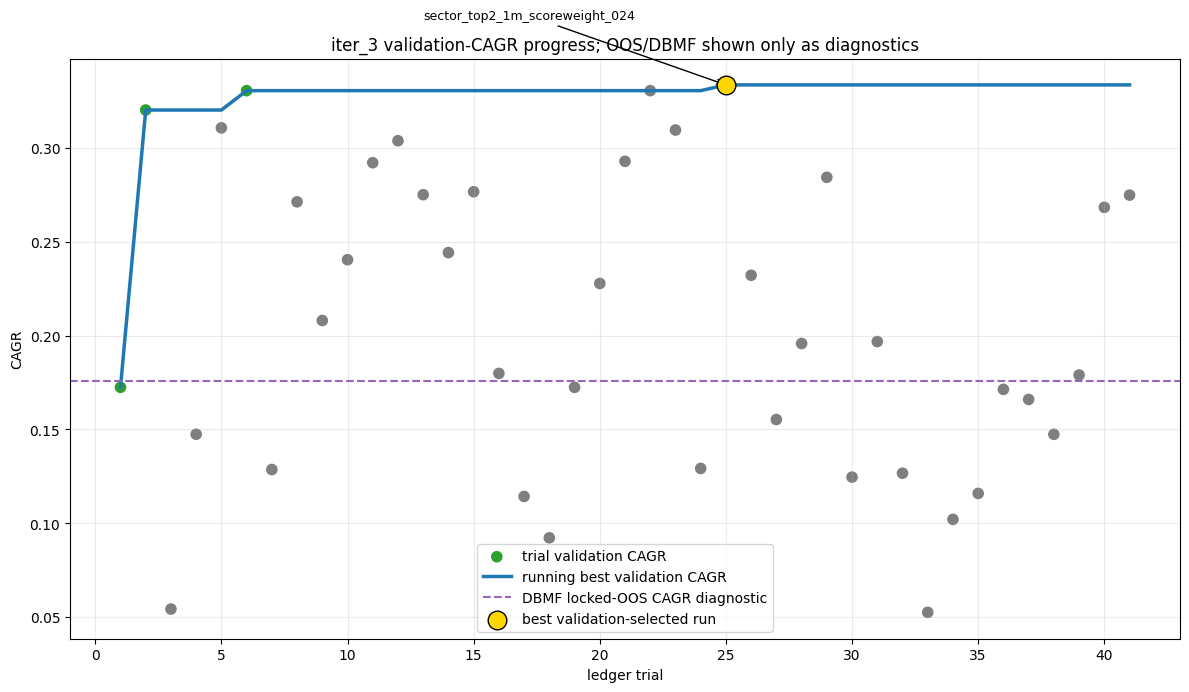

In [3]:
plot = results[['trial', 'idea_id', 'status', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr']].copy()
plot['running_best_validation_cagr'] = plot['validation_cagr'].where(~results['ruined_flag']).cummax()
fig, ax = plt.subplots(figsize=(12, 7))
colors = plot['status'].map({'keep': '#2ca02c', 'discard': '#7f7f7f', 'ruined': '#d62728', 'invalid_rationale': '#ff7f0e'}).fillna('#7f7f7f')
ax.scatter(plot['trial'], plot['validation_cagr'], c=colors, s=54, label='trial validation CAGR')
ax.plot(plot['trial'], plot['running_best_validation_cagr'], color='#1f77b4', linewidth=2.5, label='running best validation CAGR')
ax.axhline(float(best['benchmark_oos_cagr']), color='#9467bd', linestyle='--', linewidth=1.5, label='DBMF locked-OOS CAGR diagnostic')
ax.scatter([int(best['trial'])], [float(best['validation_cagr'])], color='gold', edgecolor='black', s=180, zorder=5, label='best validation-selected run')
ax.annotate(str(best['idea_id']), xy=(int(best['trial']), float(best['validation_cagr'])), xytext=(int(best['trial']) - 12, float(best['validation_cagr']) + 0.035), arrowprops={'arrowstyle': '->', 'color': 'black'}, fontsize=9)
ax.set_title('iter_3 validation-CAGR progress; OOS/DBMF shown only as diagnostics')
ax.set_xlabel('ledger trial')
ax.set_ylabel('CAGR')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig('progress.png', dpi=180)
plt.show()


## Best run interpretation

The selected run is the highest non-ruined validation-CAGR strategy in the ledger. OOS CAGR and DBMF excess are locked diagnostics, not the selection criterion.


In [4]:
best[['idea_id', 'title', 'mechanism', 'expected_assets', 'feature_inputs', 'human_notes', 'train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf', 'ruined', 'status']].to_frame('best_run')


,best_run
idea_id,sector_top2_1m_scoreweight_024
title,Sector/style top-two one-month score-weighted ...
mechanism,Retail-accessible ETF momentum can persist bec...
expected_assets,SPY;QQQ;RSP;IWM;USMV;QUAL;MTUM;VLUE;XLK;XLY;XL...
feature_inputs,price_momentum_21d;score_weighted_top2
human_notes,Top-two 21-day sector/style macro ETF momentum...
train_cagr,0.096288
validation_cagr,0.33355
oos_cagr,0.627231
benchmark_oos_cagr,0.175971
